# AI-ML Assignment 5

## Employee Attrition Prediction using Decision Tree and Random Forest Classification

**Name:** Prathmesh Chedge 

**Registration Number:** 23BEC10046

**Course:** Artificial Intelligence and Machine Learning

# Task 1 : Data Understanding

## Import Libraries

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


## Loading the Dataset

In [77]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Display First Five Records

In [78]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Dataset Shape

In [79]:
print("Rows and Columns :", df.shape)

Rows and Columns : (1470, 35)


## Numerical Features

In [80]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

print("Number of Numerical Features:", len(numerical_features))
print()

for feature in numerical_features:
    print(feature)

Number of Numerical Features: 26

Age
DailyRate
DistanceFromHome
Education
EmployeeCount
EmployeeNumber
EnvironmentSatisfaction
HourlyRate
JobInvolvement
JobLevel
JobSatisfaction
MonthlyIncome
MonthlyRate
NumCompaniesWorked
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StandardHours
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager


## Categorical Features

In [81]:
categorical_features = df.select_dtypes(include=["object", "string"]).columns

print("Number of Categorical Features:", len(categorical_features))
print()

for feature in categorical_features:
    print(feature)

Number of Categorical Features: 9

Attrition
BusinessTravel
Department
EducationField
Gender
JobRole
MaritalStatus
Over18
OverTime


## Target Variable

In [82]:
target_variable = "Attrition"

print("Target Variable:", target_variable)

print()

print(df[target_variable].value_counts())

Target Variable: Attrition

Attrition
No     1233
Yes     237
Name: count, dtype: int64


## Dataset Information

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

## Summary Statistics

In [84]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Task 2 : Data Preprocessing

## Check for Missing Values

In [85]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values in Each Column:

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInC

## Remove Unnecessary Columns

In [86]:
print("Unique values in each column:\n")

for column in df.columns:
    print(f"{column}: {df[column].nunique()}")

Unique values in each column:

Age: 43
Attrition: 2
BusinessTravel: 3
DailyRate: 886
Department: 3
DistanceFromHome: 29
Education: 5
EducationField: 6
EmployeeCount: 1
EmployeeNumber: 1470
EnvironmentSatisfaction: 4
Gender: 2
HourlyRate: 71
JobInvolvement: 4
JobLevel: 5
JobRole: 9
JobSatisfaction: 4
MaritalStatus: 3
MonthlyIncome: 1349
MonthlyRate: 1427
NumCompaniesWorked: 10
Over18: 1
OverTime: 2
PercentSalaryHike: 15
PerformanceRating: 2
RelationshipSatisfaction: 4
StandardHours: 1
StockOptionLevel: 4
TotalWorkingYears: 40
TrainingTimesLastYear: 7
WorkLifeBalance: 4
YearsAtCompany: 37
YearsInCurrentRole: 19
YearsSinceLastPromotion: 16
YearsWithCurrManager: 18


In [87]:
columns_to_remove = ["EmployeeCount", "Over18", "StandardHours"]

df = df.drop(columns=columns_to_remove)

print("Removed Columns:")
print(columns_to_remove)

print("\nUpdated Dataset Shape:", df.shape)

Removed Columns:
['EmployeeCount', 'Over18', 'StandardHours']

Updated Dataset Shape: (1470, 32)


## Encode Categorical Variables

In [88]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=["object", "string"]).columns

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


## Split Dataset into Training and Testing Sets

In [89]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (1176, 31)
Testing Features Shape: (294, 31)
Training Labels Shape: (1176,)
Testing Labels Shape: (294,)


# Task 3 : Model Development

## Model 1 : Decision Tree Classifier

In [90]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

dt_predictions = decision_tree.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Model 2 : Random Forest Classifier

In [91]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Prediction Samples

In [92]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Decision Tree Prediction": dt_predictions,
    "Random Forest Prediction": rf_predictions
})

prediction_df.head(10)

,Actual,Decision Tree Prediction,Random Forest Prediction
0,0,0,0
1,0,0,0
2,1,0,0
3,0,0,0
4,0,0,0
5,0,1,0
6,0,1,0
7,0,0,0
8,0,0,0
9,0,0,0


# Task 4 : Model Evaluation and Comparison

## Evaluation Metrics

In [93]:
decision_tree_accuracy = accuracy_score(y_test, dt_predictions)
decision_tree_precision = precision_score(y_test, dt_predictions)
decision_tree_recall = recall_score(y_test, dt_predictions)
decision_tree_f1 = f1_score(y_test, dt_predictions)

random_forest_accuracy = accuracy_score(y_test, rf_predictions)
random_forest_precision = precision_score(y_test, rf_predictions)
random_forest_recall = recall_score(y_test, rf_predictions)
random_forest_f1 = f1_score(y_test, rf_predictions)

evaluation_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Decision Tree": [
        decision_tree_accuracy,
        decision_tree_precision,
        decision_tree_recall,
        decision_tree_f1
    ],
    "Random Forest": [
        random_forest_accuracy,
        random_forest_precision,
        random_forest_recall,
        random_forest_f1
    ]
})

evaluation_results

,Metric,Decision Tree,Random Forest
0,Accuracy,0.758503,0.870748
1,Precision,0.119048,0.571429
2,Recall,0.128205,0.102564
3,F1-Score,0.123457,0.173913


## Confusion Matrix - Decision Tree

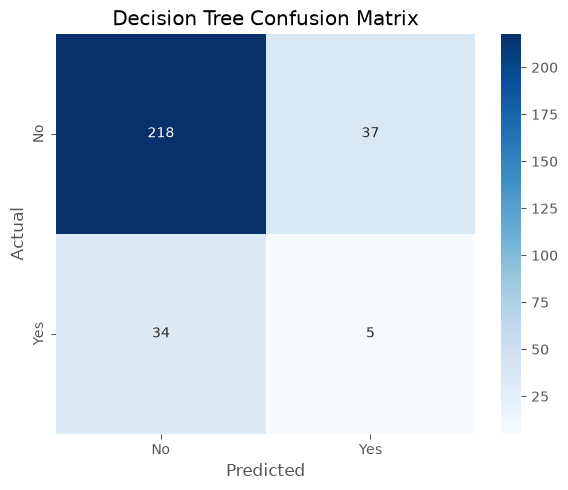

In [94]:
decision_tree_cm = confusion_matrix(y_test, dt_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(
    decision_tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("outputs/confusion_matrix_decision_tree.png")

plt.show()

## Confusion Matrix - Random Forest

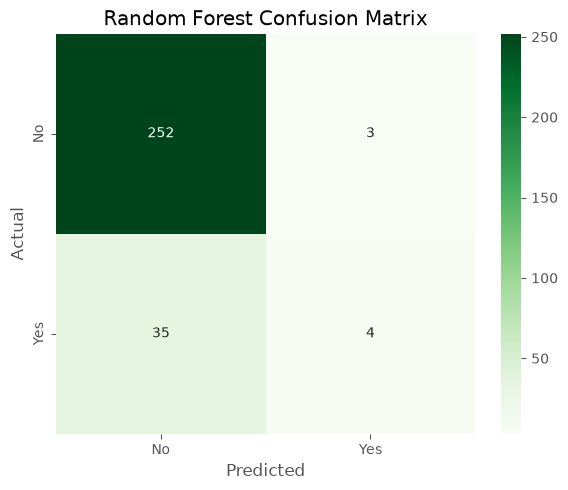

In [95]:
random_forest_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("outputs/confusion_matrix_random_forest.png")

plt.show()

## Feature Importance - Random Forest

In [96]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
16,MonthlyIncome,0.083404
19,OverTime,0.066015
0,Age,0.055029
2,DailyRate,0.050876
24,TotalWorkingYears,0.048986
17,MonthlyRate,0.047899
10,HourlyRate,0.045838
7,EmployeeNumber,0.045186
27,YearsAtCompany,0.044457
4,DistanceFromHome,0.042537


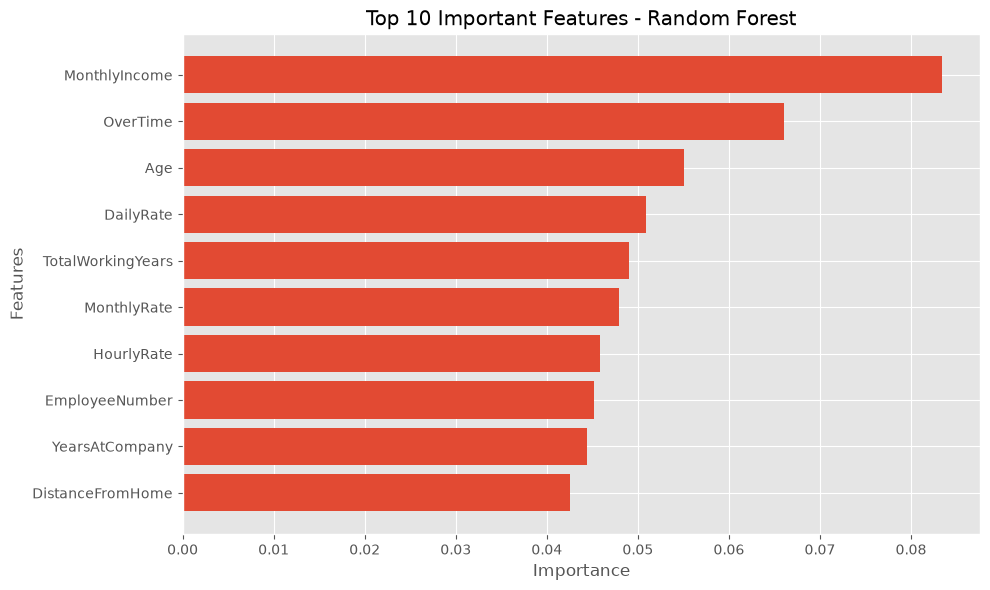

In [97]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig("outputs/feature_importance.png")

plt.show()

## Observations

1. The Random Forest model achieved a higher accuracy (87.07%) than the Decision Tree model (75.85%), indicating better overall prediction performance.

2. Random Forest obtained a much higher precision (57.14%) compared to Decision Tree (11.90%), meaning it made fewer false positive predictions.

3. Both models showed relatively low recall because the dataset is imbalanced, with significantly more employees staying than leaving.

4. The most important features identified by the Random Forest model were MonthlyIncome, OverTime, Age, DailyRate, and TotalWorkingYears, suggesting these factors have the greatest influence on employee attrition prediction.

# Task 5 : Conclusion

The objective of this assignment was to predict employee attrition using Decision Tree and Random Forest classification models and compare their performance. Based on the evaluation results, the Random Forest model performed better than the Decision Tree model. It achieved a higher accuracy of 87.07% and a much better precision, making it more reliable for predicting employee attrition. Random Forest generally outperforms Decision Trees because it combines the predictions of multiple decision trees, reducing overfitting and improving the model's ability to generalize to unseen data. In contrast, a single Decision Tree can easily overfit the training data, resulting in lower predictive performance. One limitation of the Decision Tree algorithm is that small changes in the dataset can produce a completely different tree structure. A limitation of Random Forest is that it requires more computational resources and training time due to the construction of multiple trees. Overall, Random Forest proved to be the better model for this employee attrition prediction task and provided more dependable classification results.

# Hyperparameter Tuning

## Random Forest Hyperparameter Tuning (max_depth)

In [101]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

rf_tuned_predictions = rf_tuned.predict(X_test)

tuned_accuracy = accuracy_score(y_test, rf_tuned_predictions)
tuned_precision = precision_score(y_test, rf_tuned_predictions)
tuned_recall = recall_score(y_test, rf_tuned_predictions)
tuned_f1 = f1_score(y_test, rf_tuned_predictions)

tuning_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Original Random Forest": [
        random_forest_accuracy,
        random_forest_precision,
        random_forest_recall,
        random_forest_f1
    ],
    "Tuned Random Forest": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

tuning_results

,Metric,Original Random Forest,Tuned Random Forest
0,Accuracy,0.870748,0.870748
1,Precision,0.571429,0.571429
2,Recall,0.102564,0.102564
3,F1-Score,0.173913,0.173913


### Hyperparameter Tuning Results

The Random Forest model was retrained by setting the `max_depth` parameter to **10** while keeping all other parameters unchanged.

The evaluation metrics remained the same as the original model:

- Accuracy: **87.07%**
- Precision: **57.14%**
- Recall: **10.26%**
- F1-Score: **17.39%**

This indicates that limiting the maximum depth of the trees to 10 did not improve or reduce the model's performance on this dataset.

### Effect of the Chosen Parameter

The `max_depth` parameter controls the maximum depth of each decision tree in the Random Forest model. A smaller value limits the complexity of the trees and can help reduce overfitting, while a larger value allows the trees to learn more detailed patterns from the training data.

In this experiment, setting `max_depth = 10` produced the same evaluation metrics as the original model. This suggests that the original Random Forest was already generalizing well, and restricting the tree depth did not have a noticeable impact on prediction performance for this dataset.